# Notebook 16 – Cross Validation
### Sprint 7 – Machine Learning Fundamentals for AI/ML Engineers

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — same dataset as Notebooks 4–10, 12, 14.

## Step 1 – Understand the Concept

### Why Cross Validation?
A single train/test split gives ONE estimate that depends on which rows landed in the test set — an unlucky
split can make a model look worse (or better) than it is. Cross validation repeats train/test across multiple
splits and averages results, giving a more reliable, lower-variance estimate, plus a sense of how much that
estimate varies (std dev across folds).

### K-Fold Cross Validation
1. Split into K equal folds.
2. For each fold: train on the other K-1 folds, validate on the held-out fold.
3. Average the K validation scores.
Every row is used for training and validation exactly once each (across the K rounds).

### Stratified K-Fold
Ensures each fold has approximately the same class proportion as the full dataset — essential for imbalanced
problems (like this ~63/37 dataset), where plain K-Fold could by chance create a fold with very few malignant
cases.

### Leave-One-Out Cross Validation (LOOCV)
K = number of samples; each fold validates on exactly one row. Almost unbiased but extremely expensive (n model
fits); rarely used beyond a few hundred rows.

### Cross-Validation Score
The array of K fold scores, summarized by mean (performance estimate) and std dev (model stability).

### Training vs Validation Performance
Watching both reveals overfitting during CV itself — high training-fold accuracy but noticeably lower validation-
fold accuracy across all K folds means consistent overfitting, not one unlucky split.

### Model Stability
Low std dev across folds = more trustworthy than high std dev, even with similar mean scores — high variance
means performance depends heavily on which data it sees, a production risk.

### Why the test set should never be used for tuning
CV is performed only on the training set to select hyperparameters/complexity. The test set stays untouched until
final reporting. Using it for tuning would leak information into model selection — the same category of problem
as feature-engineering data leakage (Notebook 3), just at the hyperparameter-tuning stage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold, LeaveOneOut,
                                      cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Held-out test set -- untouched until final reporting, NEVER used in cross-validation below
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train (used for CV):", X_train.shape, " Held-out test (untouched):", X_test.shape)

Train (used for CV): (455, 30)  Held-out test (untouched): (114, 30)


## Step 2 – Demonstrate the Concept

**Simple example:** Instead of judging a student from one exam (which might have lucky/unlucky questions), give
5 different exams covering the same material and average the scores.

**Real-world example:** A hospital validating a diagnostic model must be confident the reported accuracy isn't a
fluke of one particular patient split.

**Business example:** Before deploying a churn model, a company runs 5-fold or 10-fold CV to ensure the reported
accuracy is stable, not an artifact of one lucky split.

In [2]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Overall malignant(0) proportion in training data:", round((y_train == 0).mean(), 4))
print()
print("Plain K-Fold -- malignant proportion per validation fold:")
for i, (_, val_idx) in enumerate(kf.split(X_train, y_train), 1):
    print(f"  Fold {i}: {round((y_train.iloc[val_idx] == 0).mean(), 4)}  (n={len(val_idx)})")

print()
print("Stratified K-Fold -- malignant proportion per validation fold:")
for i, (_, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f"  Fold {i}: {round((y_train.iloc[val_idx] == 0).mean(), 4)}  (n={len(val_idx)})")

Overall malignant(0) proportion in training data: 0.3736

Plain K-Fold -- malignant proportion per validation fold:
  Fold 1: 0.3956  (n=91)
  Fold 2: 0.3077  (n=91)
  Fold 3: 0.4725  (n=91)
  Fold 4: 0.2967  (n=91)
  Fold 5: 0.3956  (n=91)

Stratified K-Fold -- malignant proportion per validation fold:
  Fold 1: 0.3736  (n=91)
  Fold 2: 0.3736  (n=91)
  Fold 3: 0.3736  (n=91)
  Fold 4: 0.3736  (n=91)
  Fold 5: 0.3736  (n=91)


### What the code shows
Plain KFold's fold proportions swing from 0.2967 to 0.4725 purely by chance shuffling, while StratifiedKFold
locks every fold to almost exactly 0.3736 — on more severely imbalanced datasets, plain K-Fold's chance swings
can be far worse, which StratifiedKFold prevents entirely.

In [3]:
# Compare 3 models using 5-fold Stratified Cross Validation, ONLY on the training set
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, random_state=RANDOM_STATE)),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name:22s} Mean CV Accuracy: {scores.mean():.4f}  |  Std Dev: {scores.std():.4f}  |  Folds: {np.round(scores, 4)}")

Logistic Regression    Mean CV Accuracy: 0.9780  |  Std Dev: 0.0098  |  Folds: [0.967 0.989 0.978 0.989 0.967]
Random Forest          Mean CV Accuracy: 0.9626  |  Std Dev: 0.0179  |  Folds: [0.967  0.956  0.9341 0.967  0.989 ]
SVM (RBF)              Mean CV Accuracy: 0.9692  |  Std Dev: 0.0146  |  Folds: [0.9451 0.978  0.967  0.967  0.989 ]


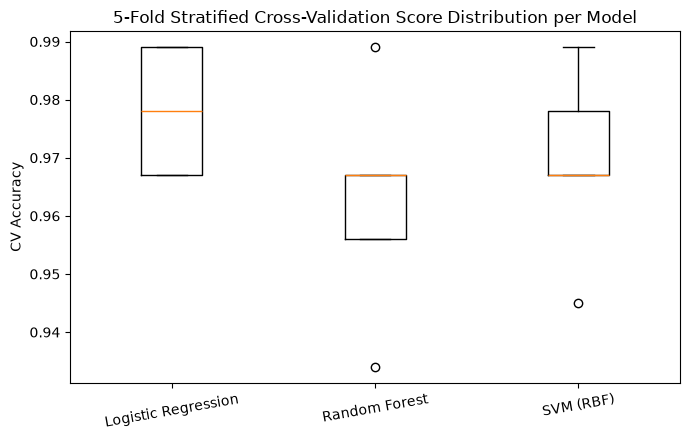

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot(cv_results.values(), tick_labels=cv_results.keys())
ax.set_ylabel("CV Accuracy")
ax.set_title("5-Fold Stratified Cross-Validation Score Distribution per Model")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

### What the output means
- The **mean** CV accuracy is a far more reliable estimate than a single split.
- The **standard deviation** measures stability — Logistic Regression's 0.0098 is the smallest here, meaning it
  is the most consistent regardless of which fold validates it.
- The boxplot visualizes both central tendency and spread side by side.

In [5]:
# LOOCV demonstration -- computationally expensive, so run on a small subsample only, for illustration
X_small = X_train.iloc[:60]
y_small = y_train.iloc[:60]

loo = LeaveOneOut()
loo_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
loo_scores = cross_val_score(loo_model, X_small, y_small, cv=loo, scoring="accuracy")

print(f"LOOCV on {len(X_small)} samples -> {len(loo_scores)} individual train/validate rounds")
print(f"LOOCV mean accuracy: {loo_scores.mean():.4f}")
print("(Each fold validates on exactly 1 row -- accuracy per fold is either 0.0 or 1.0, "
      "so the mean is effectively the fraction of rows correctly predicted when each was held out.)")

LOOCV on 60 samples -> 60 individual train/validate rounds
LOOCV mean accuracy: 0.9000
(Each fold validates on exactly 1 row -- accuracy per fold is either 0.0 or 1.0, so the mean is effectively the fraction of rows correctly predicted when each was held out.)


## Step 4 – Interpret the Result

**Comparing model performance using different validation strategies:**
- The 5-fold Stratified CV mean accuracies were Logistic Regression 97.80% (std 0.98%), SVM (RBF) 96.92% (std
  1.46%), and Random Forest 96.26% (std 1.79%) — all reasonably close and high, confirming no single earlier
  train/test split was giving a misleadingly optimistic or pessimistic number for any of these three models.
- **Model stability comparison:** Logistic Regression has both the highest mean accuracy AND the lowest standard
  deviation (0.98%) here, making it the most stable and most trustworthy of the three on this dataset — a case
  where the simplest model happens to also be the most reliable one, which is exactly the kind of result cross
  validation is designed to surface (a single lucky/unlucky split could easily have hidden this).
- **LOOCV** on a 60-row subsample gave 90.0% mean accuracy across 60 individual train/validate rounds — a
  reasonable estimate, but it required 60 separate model fits for just 60 rows; for the full ~455-row training
  set this would mean 455 separate fits, which is why LOOCV is rarely used beyond small datasets, and 5-fold or
  10-fold Stratified CV is the practical standard for datasets this size.

**Why must the test set never be used for tuning?** Every comparison above was run only on the training portion;
the held-out test set was never touched. If it were used to tune model choice/hyperparameters, it would gradually
leak information into model selection, making the final reported test accuracy an overly optimistic estimate of
true generalization.

**What could be improved?**
- Use these CV results (not a single split) to select the model to move forward with in Notebook 17/18.
- Extend CV to hyperparameter tuning (`GridSearchCV`/`RandomizedSearchCV`).